# Module Tutorial: photonHDF5 and loadraw

smfBursts can load either Picoquant or Beckr & Hickl .ptu or .spc files,
but there are all internally coerced into a form like that of [Photon-HDF5](https://photon-hdf5.readthedocs.io/).

When any raw file is loaded, it is loaded as a "partial" Photon-HDF5 file.
This is done by wrapping [phconvert](https://phconvert.readthedocs.io/).

When a raw file or Photon-HDF5 file is loaded, it is loaded as a `PhotonHDF5Data` object,
which is a python representation of a photon-HDF5 file (which may be incomplete).

While the tutorials are far less complete, looking at the [phconvert](https://phconvert.readthedocs.io/)
documentation and tutorials will help you understand how data is loaded in smfBursts.

Basic imports:

In [1]:
import numpy as np

import smfbursts as smf

## Photon-HDF5 files

Let's load a Photon-HDF5 file so we can examine the structure of the `PhotonHDF5Data` object:

In [2]:
hdf5 = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')

The keys of the `PhotonHDF5Data` are the same as those of a standard 
[photon-HDF5 file](https://photon-hdf5.readthedocs.io/en/stable/phdata.html).

These keys can also be accessed as attributes.

In [3]:
hdf5['acquisition_duration'], hdf5.acquisition_duration

(array(5009.), array(5009.))

Each top-level group of a Photon-HDF5 files is loaded as specialized type.
The two most important are `photon_data` (or `photon_data0`, `photon_data1`, ...) and `setup`.
We will address each of these in turn.

The `photon_data` group(s) are loaded as a list of the "equivalent" `PhGroupRaw` type.

In [4]:
hdf5.photon_data

(<class 'smfbursts.photonHDF5.PhGroupRaw'>
 photon_data = <smfbursts.photonHDF5.PhEventsRawDiskDict object at
     0x719a2f472e70>
 meas_specs = {'alex_excitation_period1': [2250, 3750],
     'alex_excitation_period2': [130, 1850], 'detectors_specs':
     {'spectral_ch1': array([1], dtype=uint8), 'spectral_ch2':
     array([0], dtype=uint8)}, 'laser_repetition_rate':
     array(20000000.), 'measurement_type': 'smFRET-nsALEX'}
 time_specs = {'timestamps_unit': array(5.e-08)}
 nano_specs = {'tcspc_num_bins': 4096, 'tcspc_range':
     5.003356933593743e-08, 'tcspc_unit': 1.22152268886566e-11},)

In [5]:
hdf5.photon_data[0].photon_data['dets']

array([0, 1, 1, ..., 1, 1, 1], shape=(11836058,), dtype=uint8)

Inside the `photon_data` group there are arrays of photon data, and groups that define specifications.
The arrays are loaded into a special `PhEventsRawDiskDict` data type, and the specifications are loaded as
a subclass of dictionary, a `MutDict`, which adds the ability to detect if values have been modified since object creation.

The `PhEventsRawDiskDict` also behaves like a dictionary,
but it can link the arrays to the HDF5 file (note that this linking only occurs if the data is loaded "ondisk")
(it is a subclass of diskdict, see the `smf.datamodel.diskdict` module).
The photon data arrays are renamed from the Photon-HDF5 specification to shorter names as follows:

- `timestamps` $\rightarrow$ `times`
- `detectors` $\rightarrow$ `dets`
- `nanotimes` $\rightarrow$ `nanos`
- `particles` remains the same as `particles

These can also be accessed as properties.
And even as properties directly from the `PhGroupRaw` object itself.

### Detecting changes

Both `PhotonHDF5Data` and `PhGroupRaw` have the `mut` property, which detects if the object has been changed since creation.

> **Note**
>
> The `setup` attribute of `PhotonHDF5Data` is stored as a `SetupSpec`,
> wich similar to `PhGroupGroup`, has a `mut` property.

In [6]:
hdf5.mut

False

If such an object has been changed since creation, 
it indicates that the user has manipulated some setting or data.
Therefore for reproducibility, it may be that the data should be resaved or the alteration noted.

### Excitation Periods

The definition of alternation periods is probably the component you will most likely want to change.

There are set using the `photon_data[x]['meas_spces']['alex_excitation_periodY']` arrays.

> **Explantion**
>
> In Photon-HDF5 the excitation periods are set in the
> `/photon_data/measurement_specs/alex_excitation_periodY` arrays

We can check the current excitation period settings with the `smf.plot.alternation_hist()` function.

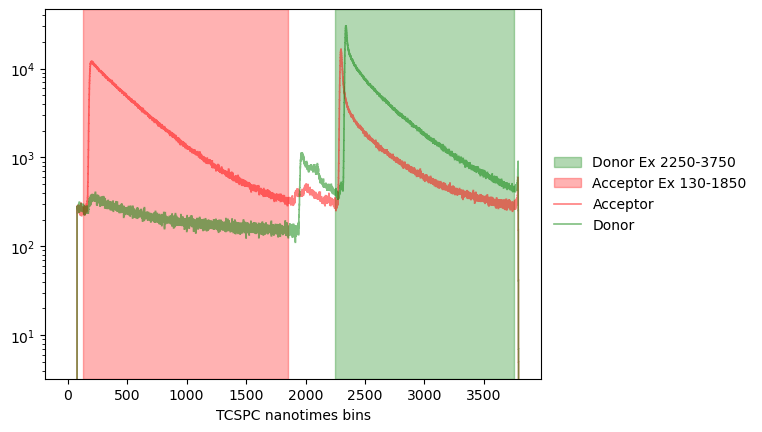

In [7]:
smf.plot.alternation_hist(hdf5)

To change a period, it is as simple as:

In [8]:
hdf5.photon_data[0]['meas_specs']['alex_excitation_period1'] = np.array([2250, 3600])

To check the change, let's plot it again

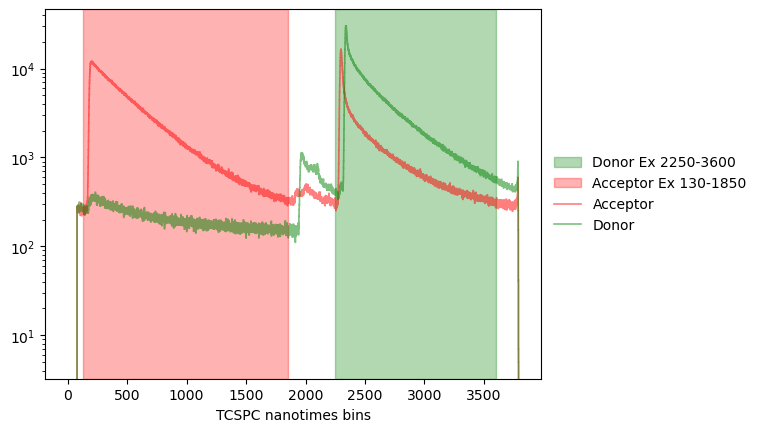

In [9]:
smf.plot.alternation_hist(hdf5)

We can also verify that the settings were changed using the `mut` property:

In [10]:
hdf5.mut

True

Excitation periods can even be added or removed:

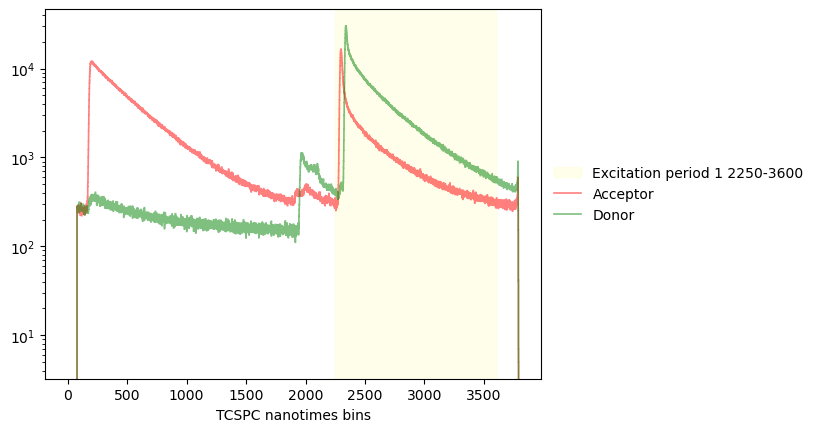

In [11]:
# remove a period
aex_per = hdf5.photon_data[0]['meas_specs'].pop('alex_excitation_period2')
smf.plot.alternation_hist(hdf5)

Add the periods back:

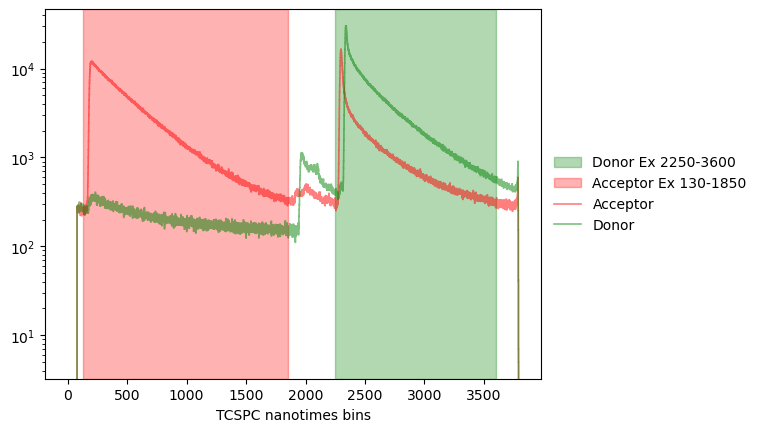

In [12]:
hdf5.photon_data[0]['meas_specs']['alex_excitation_period2'] = aex_per
smf.plot.alternation_hist(hdf5)

It should be noted that smfbursts supports arbitrary numbers of excitation periods:

array([2000, 2100])

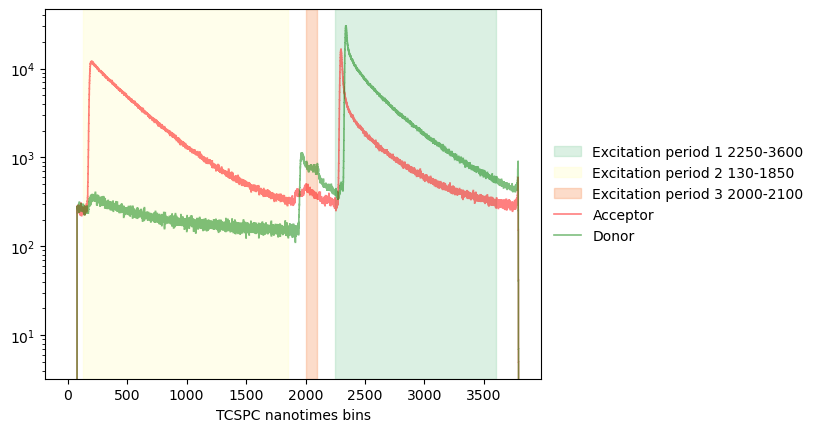

In [13]:
hdf5.photon_data[0]['meas_specs']['alex_excitation_period3'] = np.array([2000,2100])
smf.plot.alternation_hist(hdf5)
hdf5.photon_data[0]['meas_specs'].pop('alex_excitation_period3') # so that the old configuration is maintained

### Converting to HDf5 file or dictionary

`PhotonHDF5Data` objects have the as_photonHDF5 property which converts the object
into a dictionary that can be saved by `phconvert.hdf5.save_photon_hdf5` as a photon-HDF5 file.

In [14]:
hdf5_dict = hdf5.as_photonHDF5_dict
hdf5_dict.keys(), hdf5_dict['photon_data']['timestamps']

(dict_keys(['setup', 'acquisition_duration', 'description', 'identity', 'provenance', 'photon_data']),
 array([       25378,        26388,        62791, ..., 100187044027,
        100187047771, 100187059037], shape=(11836058,)))

Or, the method `save_photonHDF5` can be used to save the file directly (provided there are no missing fields).

In [15]:
hdf5.provenance

{'creation_time': '2020-12-02 21:50:18',
 'filename': 'HP3_TE300_SPC630.spc',
 'filename_full': 'D:\\Eitan\\HP3_TE300_SPC630.spc',
 'modification_time': '2020-12-02 21:51:01',
 'software': 'Becker & Hickl SPCM'}

In [16]:
hdf5.save_photonHDF5('test_save.hdf5')

Saving: test_save_new_copy.hdf5


<closed File>

### Working with older or semi-broken HDF5 files

> **Note**
>
> These tips and tricks are alse helpful when loading from a company's format,
> as it involves completing missing fields etc.

As photon-HDF5 developed, newer versions have tightened the definition and requirements for certain parameters.
Additionally, older versions of phconvert were not as good at detecting certain irregularities.

This means that there are occasionally ambiguities in older files that the user must resovle manually.

Lets load such a file:

In [17]:
oldfile = smf.photonHDF5.load('data/dsdna_d7_d17_50_50_1.hdf5')

In [18]:
oldfile.description

b'A demonstrative smFRET-nsALEX measurement.'

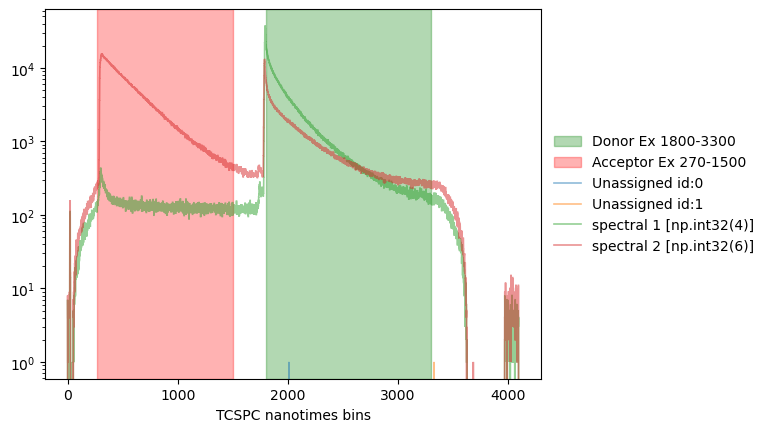

In [19]:
smf.plot.alternation_hist(oldfile)

This file was created with an older version of phconvert.
In the detectors array, there are 4 unique indexes, but only 2 of them are defined by `detectors_specs`.

In [20]:
# all detector indexes in the detectors array
np.unique(oldfile.photon_data[0].dets)

array([0, 1, 4, 6], dtype=uint8)

In [21]:
# defined detectors
oldfile.photon_data[0].meas_specs['detectors_specs']

{'spectral_ch1': array([4], dtype=int32),
 'spectral_ch2': array([6], dtype=int32)}

The other 2 are marker indexes, which do not indicate a photon, but some other type of event.
Older versions of the photon-HDF5 spec were technically not supposed to contain such indexes,
but phconvert did not check, and it is not uncommon to have such events.

In the latest update to the photon-HDF5 spec, the `non_photon_idX` arrays were added to allow support for these events.
Therefore to bring this old-file "up-to-spec", we should add `'non_photon_id1'` to the detectors specs:

In [22]:
oldfile.photon_data[0].meas_specs['detectors_specs']['non_photon_id1'] = np.array([0, 1], dtype=np.int32)

Another aspect is that the [/setup/detectors](https://photon-hdf5.readthedocs.io/en/0.5/phdata.html#detectors-group)
group was added, for analysis with smfbursts, this group is not strictly necessary (and can be infered),
but it will be necessary to fill it out if you wish to resave (and save further data analysis)
the file.

In [23]:
tcspc_unit = oldfile.photon_data[0].nano_specs['tcspc_unit']

oldfile.setup['detectors'] = {'id':np.array([0,1,4,6], dtype=np.int32), 
                              'tcspc_unit':np.array([0,0, tcspc_unit, tcspc_unit])}

## Loading Non-HDF5 data with loadraw

The closely releated `loadraw` module uses [phconvert](https://phconvert.readthedocs.io/en/latest/)
to load raw files into an HDF5-like format.
But since not all parameters are specified (e.g. excitation windows), these must be specified after loading.

If the parameter is necessary for further data analysis, it must be set after loading.
If it is only required for saving as a photon HDF5, often data analysis can proceed without specifying it.

The loading functions are:
- `smf.loadraw.load_ptu` for picoquant ptu files
- `smf.loadraw.load_spc` for Beckr & Hicklk files
- `smf.loadraw.load_sm` for the speicalized `.sm` file format defined by the Weiss group

As an example, let's load a `.spc` file and see all the things we need to set before we can process it into a `PhotonData` 

TCSPC parameters retrived from the .SET file.


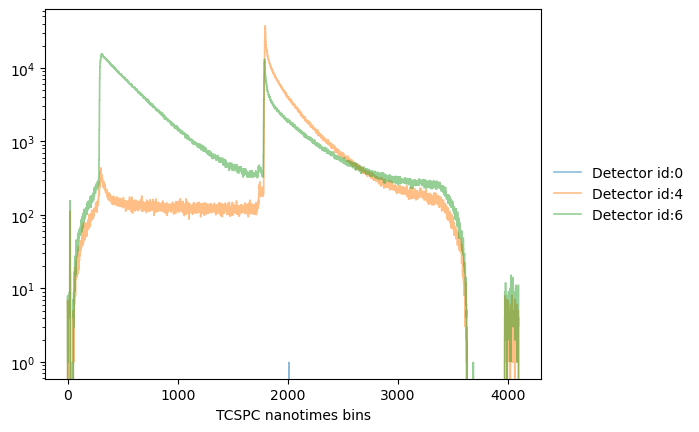

In [24]:
spc = smf.loadraw.load_spc('data/dsdna_d7d17_50_50_1.spc')
smf.plot.alternation_hist(spc)

The output is the same type of `PhotonHDF5Data` object from loading a Photon-HDF5 file.

But some elements are notably missing.
Looking at the `setup` attribute, there are a number of keys with the value of `None`.

In [25]:
spc.setup

{'num_pixels': None,
 'num_spots': 1,
 'num_spectral_ch': None,
 'num_polarization_ch': None,
 'num_split_ch': None,
 'modulated_excitation': True,
 'lifetime': True,
 'excitation_cw': None,
 'excitation_alternated': None,
 'detectors': {'id': array([0, 4, 6], dtype=uint8),
  'counts': array([      1, 3345380, 6371466]),
  'label': None},
 'laser_repetition_rates': array([16632835.20265055])}

### The setup group

Let's go through these values, and understand which are necessary, and what they mean.

> **Note**
>
> Remember, these are all based on the Photon-HDF5 spec,
> so understanding Photon-HDF5 will mean you understand this section.

1. The `num_...` values
    1. `num_pixels` **required for photon-HDF5, Not used by smfBursts** number of detectors in setup.
       This should be the number of unique detector ids specified in the `spectral/polarization/split_chN` fields of photon_data
       (Does **not** include `non_photon_idN`)
    2. `num_spots` **requied** (already set to 1) number of excitation spots in setup
       (spc and ptu files always store a single spot),
       this value changes if you combine multiple files into a single hdf5 file
    3. `num_spectral_ch` **requied** number of spectrally resolved channels. For standard FRET this is 2 (donor and acceptor).
    4. `num_polarication_ch` **requied** number of polarization resolved channels.
       This will be 1 if there are no polarizing beam splitters.
       For setups that split parallel/perpendicular, this will be 2.
       So for a MFD setup that has 4 detectors, Donor-parallel, Donor-perpendicular, Acceptor-parallel, Acceptor-perpendicular
       This will be 2 (that is, the `num_...` assume that setups are "symetric")
    5. `num_split_ch` **required** number of split channels, typically 1, if a beam splitter is used, will be 2
2. Optional Excitation metadata
    1. `excitation_alternated` **required** boolean array (1 element per laser) specifying if the laser is continuous wave **with** alternation
       ie a pulsed laser is not alternated, and a laser that is alway exciting the sample is also not alternated
    2. `excitation_cw` **required** boolean array (1 element per laser) specifying if the laser is continuous wave (False means pulsed laser)
    3. `lifetime` **required but Not used by smfBursts** simple boolean, if there is a pulsed laser source.
       This value is largely redundant in the latest Photon-HDF5 spec, but needed for backwards compatibility.
       Therefore smfBursts uses `excitation_alternated` and `excitation_cw` to infer per laser the relevant values.
    4. `modulated_exciation` **required Not used by smfBursts** simple boolean, if any excitation is modulated (on/off cycle).
       Similar to `lifetime` this is a redundant field, and thus smfBursts uses other arrays and ignores this value.
    5. `excitation_wavelengths` **optional** wavelengths (in m) of each excitation source, must match size of `excitation_alternated` etc.
       smfBursts does not require this, however, by specifying, column naming cannot include wavelengths.
       **Recomended**
    6. `excitation_polarizations` **optional** polarization angle of each excitation laser
    7. `excitation_intensity` **optional** excitation intensity at sample in $W m^{-2}$
    8. `laser_repetition_rates` **optional** repetition rate in Hz per laser **only for pulsed lasers**
3. Optional Detection metadata
    1. `detection_wavelengths` **optional** wavelengths (in m) of centers of bandpass filters for spectral streams.
       smfBursts does not require, however, like `excitation_wavelengths`, specifying will allow column names to include wavelengths.
       **Recomended**
    2. `detection_polarizations` **optional** polarization of each polarization channel.
       smfBursts does not require, but can incorporate into column names.
       **Recomended if using polarization**
    3. `detection_split_ch_ratios` **optional** ratio of beam splitter for split channels
4. Detectors group
    1. `id` **required** integer array, the detector ids of all detectors and non-photon ids used
    2. `id_hardware` **optional** integer array, this is usually unecessary, since the purpose is to provide the original ids from the original file
       these are maintained, making it typically redundant to `id` in the current form of phconvert
    3. `label` **optional** array of str, names for each `id`
    4. `tcspc_offset` **optional** (integer array) offset per record ID (as in id) to add to nanotime to account for speed of light delays between detectors
    5. `tcspc_unit` **only in rare case of differing tcspc settings between detectors**
    6. `tcspc_num_bins` **only in rare case of differing tcspc settings between detectors**
    7. `module` **multispot only, ignored by smfBursts** module (spot) of each `id`
    8. `position` **multispot only, ignored by smfBursts** positions in xy of each `id`

#### What you will usually need:

Typically, you will need to set the `num_...` values, and specify the `excitation_cw` and `excitation_alternated` in order to define the setup-scheme.
Specifying the `excitation_wavelengths` and `detection_wavelengths` is not necessary, but will make plots have better labels.

In [26]:
# Define excitation
spc.setup['num_pixels'] = 2
spc.setup['num_spectral_ch'] = 2
spc.setup['num_polarization_ch'] = 1
spc.setup['num_split_ch'] = 1
spc.setup['modulated_excitation'] = True
spc.setup['excitation_cw'] = np.array([False, False])
spc.setup['excitation_alternated'] = np.array([False, False])

### The photon_data group

The objects in `photon_data` also are likely missing some information.

There are 3 specifications attributes:
1. `meas_specs`
2. `time_specs`
3. `nano_specs`

But both `time_specs` and `nano_specs` only contain information that can be obtained from the raw data file.

In `meas_specs` on the other hand, there are usually 2 things that will need to be specified:
1. Detector assignments
2. Excitation windows


#### Assigning detector channels

If we look at the subdictionary `'detectors_specs'` inside `meas_specs`,
you will see the `'spectral_polarization_split_chN'` key, whose value is an array.
This is not a part of the Photon-HDF5 spec, but rather it shows all the unique detector ids in the data.
The numbers in this array need to be correctly apportioned between the following:
- `spectral_ch1`, ...`spectral_chN` the spectral channels (N = `setup/num_spectral_ch`)
- `polarization_ch1`, ...`polarization_chN` the spectral channels (N = `setup/num_polarization_ch`)
- `split_ch1`, ..., `split_chN` the spectral channels (N = `setup/num_split_ch`)
- `non_photon_id1`, ..., `non_photon_idN` the non-photon ids (usually event markers etc.)

The microscope and software settings you used determine which detector id goes where.
Strictly speaking, therefore, you must know your setup.

However, looking at the alternation histogram, you can often infer what is what, especially in PIE measurements.

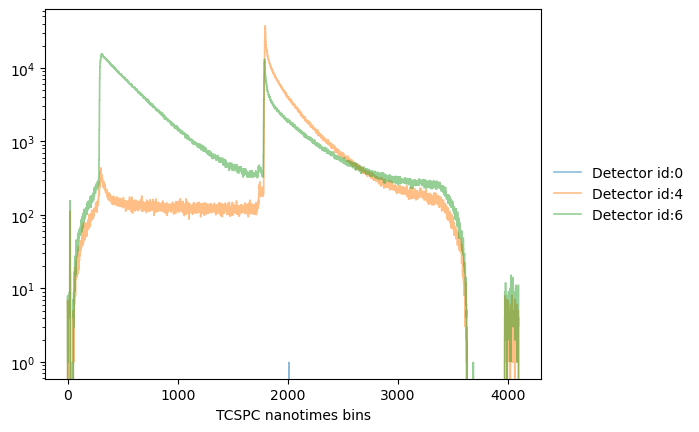

In [27]:
smf.plot.alternation_hist(spc)

From the above plot, you will note 2 clear decays (detector id4 and detector id 6), while detector id 0 has a single count.

Since I know this came from a 2 color PIE measurement, I can say that 0 must be a non-photon marker of some sort.

Next, we can infer which is donor and which is acceptor based on the histogram.
Since id 6 has 2 clear peaks, each with a decay of a significant lifetime, it must be directly excited by the acceptor laser,
while id 4 has only a single clear fluorescent decay, so it must be the donor.

Therefore we want to add to `detectors_specs` the following: 
- `spectral_ch1` (donor channel) = \[4\] (id of donor)
- `spectral_ch2` (acceptor channel) = \[6\] (id of acceptor)
- `non_photon_id1` = \[6\] (marker)

Note that we assign arrays, since in other cases, multiple ids might be assigned to the same channel.
This is especially the case when you have both spectral and polarization channels.
Then, we want to remove (pop) the uneccessary `spectral_poloarization_chN` key.

In [28]:
# define detectors
spc.photon_data[0].meas_specs['detectors_specs']['spectral_ch1'] = np.array([4], dtype=np.uint8)
spc.photon_data[0].meas_specs['detectors_specs']['spectral_ch2'] = np.array([6], dtype=np.uint8)
spc.photon_data[0].meas_specs['detectors_specs']['non_photon_id1'] = np.array([0], dtype=np.uint8)
spc.photon_data[0].meas_specs['detectors_specs'].pop('spectral_polarization_split_chN')

array([0, 4, 6], dtype=uint8)

Now if we plot the histogram again, we will see that th display is updated with the new information.

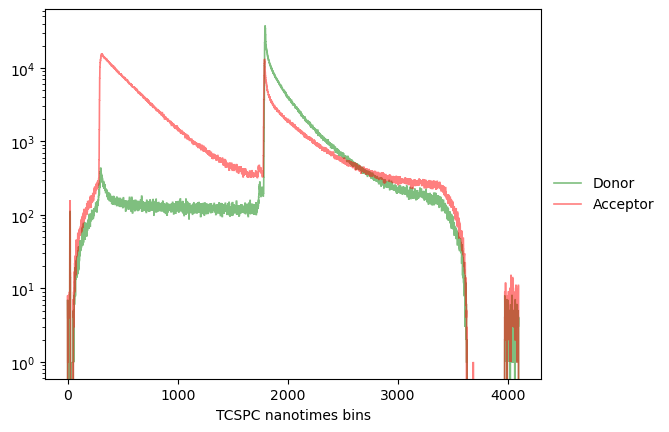

In [29]:
smf.plot.alternation_hist(spc)

#### Assigning alternation periods

The next step is assigning excitaiton periods.
These go in the `alex_excitation_periodN` keys of `meas_specs`.

These should encompass the decays, and exclude as much "pure background" as possible.
Inenvitably, the choice is a somewhat arbitrary optimization.

Let's make a guess, and then plot with `smf.plot.alternation_hist`, which will add shaded windows based on the specified periods:

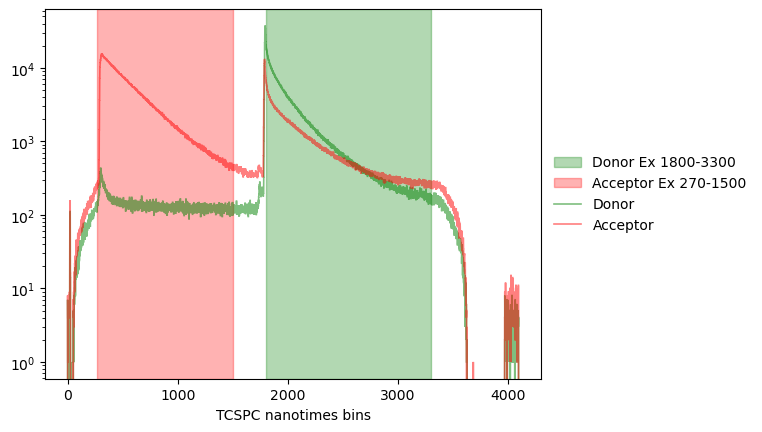

In [30]:
# Set excitation periods
spc.photon_data[0].meas_specs['alex_excitation_period1'] = np.array([1800, 3300])
spc.photon_data[0].meas_specs['alex_excitation_period2'] = np.array([270, 1500])
smf.plot.alternation_hist(spc)

Often you go through an iterative process of modifying the windows until they look "right".
Don't be afraid to re-run the cell.

### Converting to processed data

At this point the file is ready for `smf.photonHDF5.regularize_dets`, but there are 2 metadata groups that are missing information.

If you want to save as a photon-HDF5 file, these should be filled out (though not strictly necessary)

These are:
1. `"identity"` defining who created the file
    1. `author` string
    2. `author_affiliation` string
    3. More defined in [identity subgroup](https://photon-hdf5.readthedocs.io/en/0.5/phdata.html#identity-group)
2. `"sample"` defining details of the sample
    1. `num_dyes` int
    2. `dye_names` string
    3. `buffer_name` string
    4. `sample_name` string
3. `description` a string describing the experiment

In [31]:
# fill description
spc.description = 'dsDNA demonstration ns-alex dataset'
# identity information (who's responsible)
spc.identity['author'] = 'Eitan Lerner'
spc.identity['author_affiliation'] = 'UCLA'
# sample information (what's being measured)
spc.sample['num_dyes'] = 2
spc.sample['dye_names'] = 'atto 532, atto 647N'
spc.sample['buffer_name'] = 'TE 100'
spc.sample['sample_name'] = 'dsDNA demo measurement'

# add excitation/detection wavelengths
spc.setup['excitation_wavelengths'] = np.array([532e-9, 635e-9])
spc.setup['detection_wavelengths'] = np.array([580e-9, 680-9])

Now you can save as a photon HDF5.

## Keeping photon-HDF5 open

When saving as photon-HDF5, the default is for smfbursts to close the file, thus allowing other programs to access it.
This also allows for the to be reopened inside python by another module.
However, if `close=False`, smfbursts will not close the file, and instead the
[tables.File](https://www.pytables.org/usersguide/libref/file_class.html)
that smfbursts opened is remembered by the `PhotonHDF5Data` object.

The `tables.File` object is also returend by `PhotonHDF5Data.save_photonHDF5()`.

In [32]:
file = spc.save_photonHDF5('dsdna_test.hdf5', close=False)
type(file)

Saving: dsdna_test_new_copy.hdf5


tables.file.File

Keeping the file open means more disk io later on, and the created file cannot be touched by other programs.
However, it also allows recording of processed data in the `/user/smfBursts` group of the Photon-HDF5 file.

To do this, when calling `regularize_dets`, pass the `keepraw=True`, 
which means that the `PhotonData` or `PhotonDataList` object will hold on to a reference to the raw data object.
Then, the new processed data can save the values of processed columns/tables in the `/user/smfBursts` group of the Photon-HDF5 file.
**However** this means the user needs to remember to close the file with the `.close()` method when they are done with the file.

> Note
>
> smfBursts has implemented a system to close files when all smfbursts objects referencing them go out of scope.
> However this system cannot be guaranteed to close files 100% of the time.
> Therefore it is best to manually close the files.

The `PhotonData`/`PhotonDataList` object normally does not automatically record this data,
rather, the user should call the `PhotonData.save()`/`PhotonDataList.save()` (with no arguments) to save the data.
However, if the argument `autosave=True` is passed to `smf.photonHDF5.regularize_dets`, then data is saved as it is created.
The autosave option is also a property of `PhotonData`/`PhotonDataList`, and can be set to true later.

When you are done, remember to close the files.
Also note in the example below, both the raw and processed data objects call close.
This is because both are maintaining a reference to the file, and smfBursts detects this, and
will not actually close the file until both have closed it.
To force a close, pass `strict=True` to `.close()`

In [33]:
data = smf.photonHDF5.regularize_dets(spc, keepraw=True, autosave=True)
# Do analysis here
# ....
# Close files to release file reference
spc.close()
data.close()

### Reloaded with processed data

To reopen the data, and keep the original file open (and thus be able to save processed table/columns directly to it),
open the file with `ondisk=True`, and follow the same rules for `smf.photonHDF5regularize_dets` as before.

In [34]:
raw = smf.photonHDF5.load('dsdna_test.hdf5', ondisk=True)
data = smf.photonHDF5.regularize_dets(raw, keepraw=True)
# Examine data/do more anlasis
# ...
# Close files, using strict=True forces a close even if other smfBursts objects have a reference to the file
data.close(strict=True)

Thus concludes this tutorial.